Author: Daniel Abadjiev  
Date: Apr 27, 2026  
Description: Play around with some models to get a data rate.  

In [23]:
import tensorflow as tf
from datetime import datetime
from tfLoaderUtils import *
import numpy as np
import qkeras
modelType = 2

In [13]:
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_4w0i_hyperparameter_results_20260222_004048/model_trial_000.h5"
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_8w0i_hyperparameter_results_20260228_020952/model_trial_0.h5"
filepath="./model_trial_0.h5"
if modelType==2:
    filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_qi_4w0i_pareto_roc_selected/model_trial_25.h5"
    filepath="../eric/Model2_5_tahn/model2.5_quantizedinputs_8w0i_pareto_roc_selected/model_trial_065.h5"
# filepath = "../../smart-pixels-ml/DanielModels/model2_20260325.keras"
#Now trying an Ryan model
if modelType==1:
    filepath="/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/ryan/old_quantization_res/model1_quantized_4w0i_pareto/model_trial_034.h5"
co = {}       
qkeras.utils._add_supported_quantized_objects(co)
quantizedModel = tf.keras.models.load_model(filepath,custom_objects=co,compile=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir_catapult = "./hlsCatapultModel2_"+timestamp
output_dir_vitis = "./hlsVitisModel2_"+timestamp
quantizedModel.summary()

Model: "model2_5_qi_8w0i_hp_tuning"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_profile (InputLayer)      [(None, 21)]                 0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]                 0         []                            
                                                                                                  
 q_input_x_profile (QActiva  (None, 21)                   0         ['x_profile[0][0]']           
 tion)                                                                                            
                                                                                                  
 q_input_y_profile (QActiva  (None, 13)                   0         ['y_p

In [14]:

# if loadTestVectors:
#     [yTest, xTestList] = pickle.load(open(f"./testVectors{modelType}.pkl",'rb'))
#     xTest = pickle.load(open(f"./tfTestVectors{modelType}.pkl",'rb'))
    
#     # [yTest, xTestList] = pickle.load(open(f"./testVectors.pkl",'rb'))
#     # xTest = pickle.load(open(f"./tfTestVectors.pkl",'rb'))
# else:
# xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(modelType)
xTestWithNpix, yTestWithNpix, xTestListWithNpix, xTrainWithNpix, yTrainWithNpix, = flattenTfData(modelType,includenPix=True)
#     if saveTestVectors:
#         pickle.dump([yTest, xTestList],open(f"./testVectors{modelType}.pkl","wb"))
#         pickle.dump(xTest,open(f"./tfTestVectors{modelType}.pkl","wb"))
# # xTest, yTest, = flattenTfData(2,doTrain=False)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


In [28]:
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData"
model = Model2_5(tfRecordFolder = tfRecordFolder)   
configName = "justThisOne"
model.models[configName] = quantizedModel

In [42]:
model.evaluate(config_name = configName)

predictions = model.models[configName].predict(model.validation_generator, verbose=1)
print(predictions)
predictions = predictions.ravel()


Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 2s 59ms/step
✓ Model2.5 evaluation completed!
  Test Loss: 0.1931
  Test Accuracy: 0.9363
  ROC AUC: 0.9690

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.9321 (FPR = 0.067944)
    @ 98% signal efficiency: Bkg Rej = 0.8910 (FPR = 0.109019)
    @ 99% signal efficiency: Bkg Rej = 0.8611 (FPR = 0.138891)
41/41 [==============================] - 3s 62ms/step
[[ 0.8828125]
 [ 0.5703125]
 [-0.4453125]
 ...
 [ 0.953125 ]
 [-0.3046875]
 [-0.0234375]]


accepted background samples:  47339
total background samples:  330741
backgorund acceptance:  0.14313012296630898
Total background pixel count:  2000084.0
Accepted background pixel count:  175659.0
Data rate of background acceptance:  0.08782581


(175659.0, 2000084.0, 0.08782581)

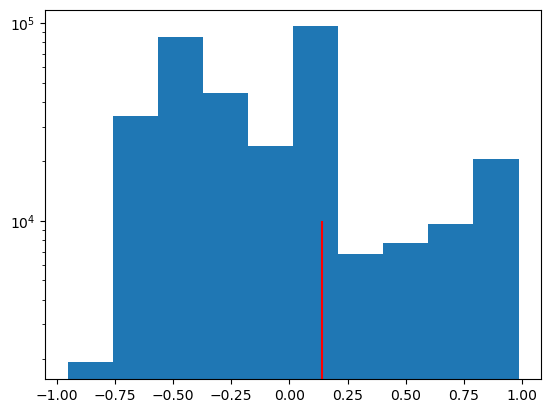

In [112]:
import matplotlib.pyplot as plt
nPixes = xTestWithNpix["nPix"]
def pixPredictToDataRate(yTest,nPixes,predictions,cut=0.138891):
    backGnd = (yTest.numpy().ravel()==0)
    # print(backGnd.shape)
    # print(predictions.shape)
    # print(predictions[backGnd])
    backTotal = (predictions[backGnd]) #I think this can be cleaned up substantially?
    backAccept = np.where(predictions[backGnd]>cut)
    plt.hist(backTotal); plt.yscale('log'); plt.vlines([cut],0,10000,"red")
    print("accepted background samples: ",np.size(backAccept))
    print("total background samples: ",np.size(backTotal))
    print("backgorund acceptance: ",np.size(backAccept)/np.size(backTotal))

    numBackPixesTotal = np.sum(nPixes.numpy()[backGnd])
    print("Total background pixel count: ",numBackPixesTotal)
    numBackPixesPostFilter = np.sum(nPixes.numpy()[backGnd][backAccept])
    print("Accepted background pixel count: ",numBackPixesPostFilter)
    print("Data rate of background acceptance: ",numBackPixesPostFilter/numBackPixesTotal)
    return numBackPixesPostFilter,numBackPixesTotal,numBackPixesPostFilter/numBackPixesTotal
pixPredictToDataRate(yTestWithNpix,nPixes,predictions)


In [67]:
def modelSpecsToDataRate(modelType,
                    tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData"
                    ):
    model = Model2_5(tfRecordFolder = tfRecordFolder)   
    configName = "justThisOne"
    model.models[configName] = quantizedModel
    model.evaluate(config_name = configName)

    predictions = model.models[configName].predict(model.validation_generator, verbose=1)
    print(predictions)
    predictions = predictions.ravel()
    genNpixAndGetDataRate(modelType,predictions)

def genNpixAndGetDataRate(modelType,predictions):

    xTestWithNpix, yTestWithNpix, xTestListWithNpix, xTrainWithNpix, yTrainWithNpix, = flattenTfData(modelType,includenPix=True)
    nPixes = xTestWithNpix["nPix"]

    pixPredictToDataRate(yTestWithNpix,nPixes,predictions)


In [61]:
(660593-661482)/661482

-0.0013439519140354538